# 1.1 – Exploratory Data Analysis
**DATA 205 | Feraol Abera | Spring 2026**

Q1: Time of day vs. violation frequency  
Q2: Most frequent violation types  
Q3: Day of week vs. stop count (Chi-square)  
Q5: Geographic heatmap

In [1]:
!pip install folium scipy --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
from scipy.stats import chi2_contingency
import os
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/data205-project'
IMG  = os.path.join(BASE, 'eda/images')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
BLUE = '#1B4F72'
RED  = '#E74C3C'

Mounted at /content/drive


In [3]:
tv = pd.read_csv(
    os.path.join(BASE, 'data/processed/traffic_violations_clean.csv'),
    parse_dates=['date_of_stop'],
    low_memory=False
)

## Summary Statistics

In [4]:
tv.describe(include='all')

,seqid,date_of_stop,time_of_stop,agency,subagency,description,location,latitude,longitude,accident,...,driver_city,driver_state,dl_state,arrest_type,geolocation,month,month_name,day_of_week,hour,time_period
count,212173,212173,212173,212173,212173,212173,212172,182076.000000,182076.000000,212173.000000,...,212134,212173,212173,212173,212173,212173.000000,212173,212173,212173.000000,212173
unique,127688,NaN,1440,1,7,4275,43375,NaN,NaN,NaN,...,2591,58,64,18,106879,NaN,12,7,NaN,4
top,07b51742-be16-49a6-bd7b-f4e6b8965f2b,NaN,16:40:00,MCP,Headquarters and Special Operations,DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,BARNESVILLE @ 109,NaN,NaN,NaN,...,SILVER SPRING,MD,MD,A - Marked Patrol,"(0.0, 0.0)",NaN,March,Tuesday,NaN,Morning
freq,40,NaN,277,212173,56973,16340,782,NaN,NaN,NaN,...,44973,195074,189410,148018,30097,NaN,27142,40427,NaN,70447
mean,NaN,2025-03-28 18:58:41.695974656,NaN,NaN,NaN,NaN,NaN,39.103456,-77.141278,0.026573,...,NaN,NaN,NaN,NaN,NaN,6.214429,NaN,NaN,12.806380,NaN
min,NaN,2024-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,35.792364,-77.826785,0.000000,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN
25%,NaN,2024-09-10 00:00:00,NaN,NaN,NaN,NaN,NaN,39.045375,-77.222521,0.000000,...,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,8.000000,NaN
50%,NaN,2025-04-14 00:00:00,NaN,NaN,NaN,NaN,NaN,39.101880,-77.149123,0.000000,...,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,13.000000,NaN
75%,NaN,2025-10-27 00:00:00,NaN,NaN,NaN,NaN,NaN,39.160970,-77.064403,0.000000,...,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,18.000000,NaN
max,NaN,2026-04-08 00:00:00,NaN,NaN,NaN,NaN,NaN,39.684162,-76.351026,1.000000,...,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,23.000000,NaN


In [5]:
tv['violation_type'].value_counts()

,count
violation_type,
Warning,143121
Citation,61262
Esero,7790


In [6]:
tv['race'].value_counts()

,count
race,
Black,65496
White,56740
Hispanic,53760
Other,24456
Asian,11579
Native American,142


In [7]:
tv['gender'].value_counts()

,count
gender,
M,143067
F,68462
U,644


## Q1 — Violations by Hour of Day

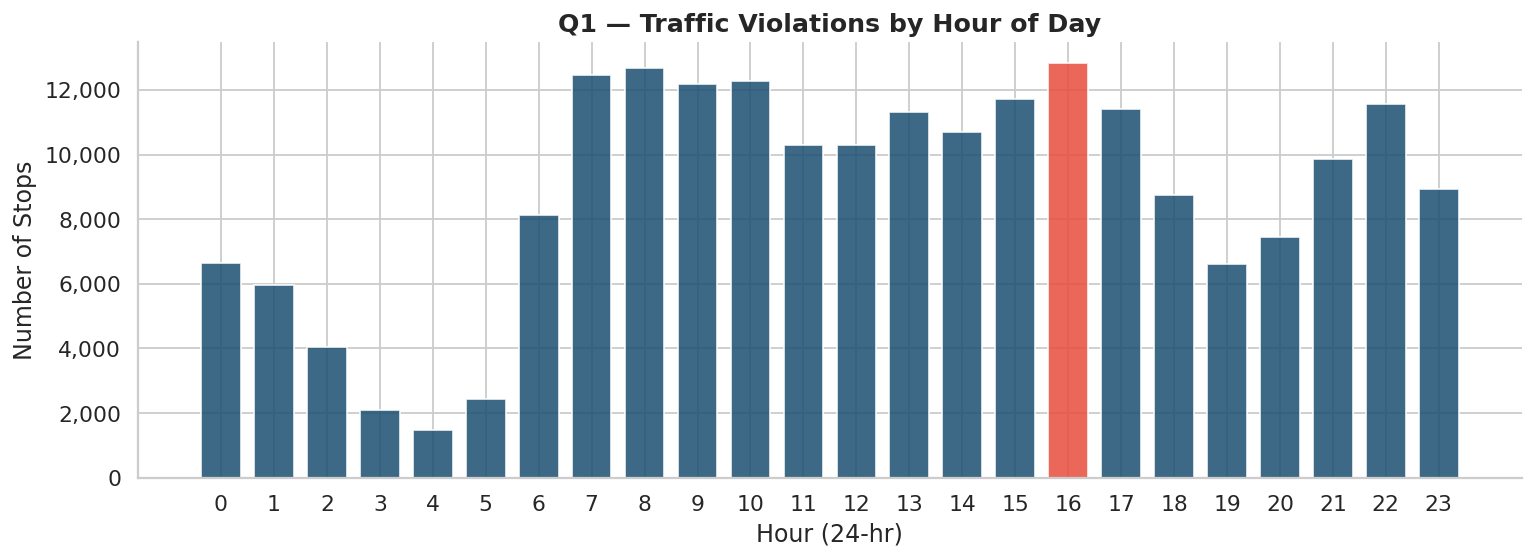

In [8]:
hour_counts = tv['hour'].value_counts().sort_index()
peak = hour_counts.idxmax()

colors = [RED if h == peak else BLUE for h in hour_counts.index]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(hour_counts.index, hour_counts.values, color=colors, alpha=0.85, width=0.75)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Q1 — Traffic Violations by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (24-hr)')
ax.set_ylabel('Number of Stops')
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'q1_violations_by_hour.png'), bbox_inches='tight')
plt.show()

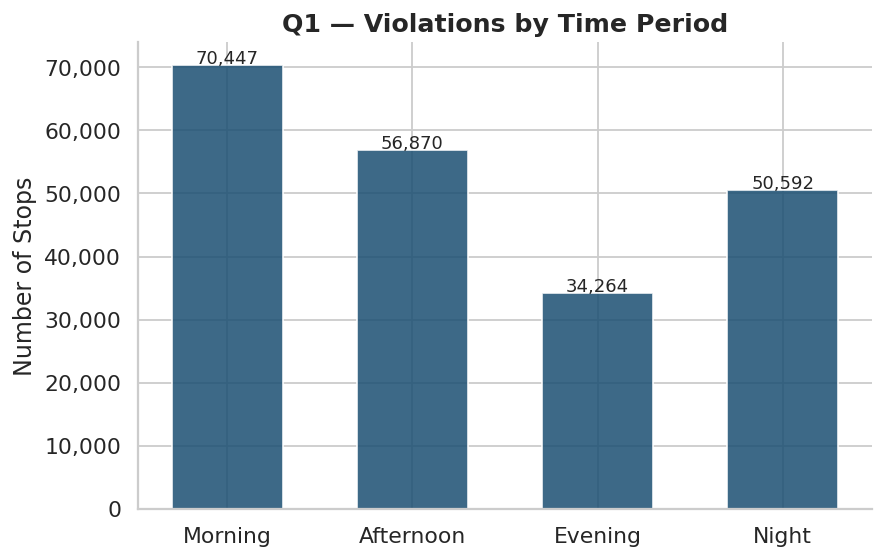

In [9]:
period_order  = ['Morning', 'Afternoon', 'Evening', 'Night']
period_counts = tv['time_period'].value_counts().reindex(period_order).dropna()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(period_counts.index, period_counts.values, color=BLUE, alpha=0.85, width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Q1 — Violations by Time Period', fontsize=14, fontweight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Number of Stops')
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'q1_violations_by_period.png'), bbox_inches='tight')
plt.show()

## Q2 — Most Frequent Violation Types

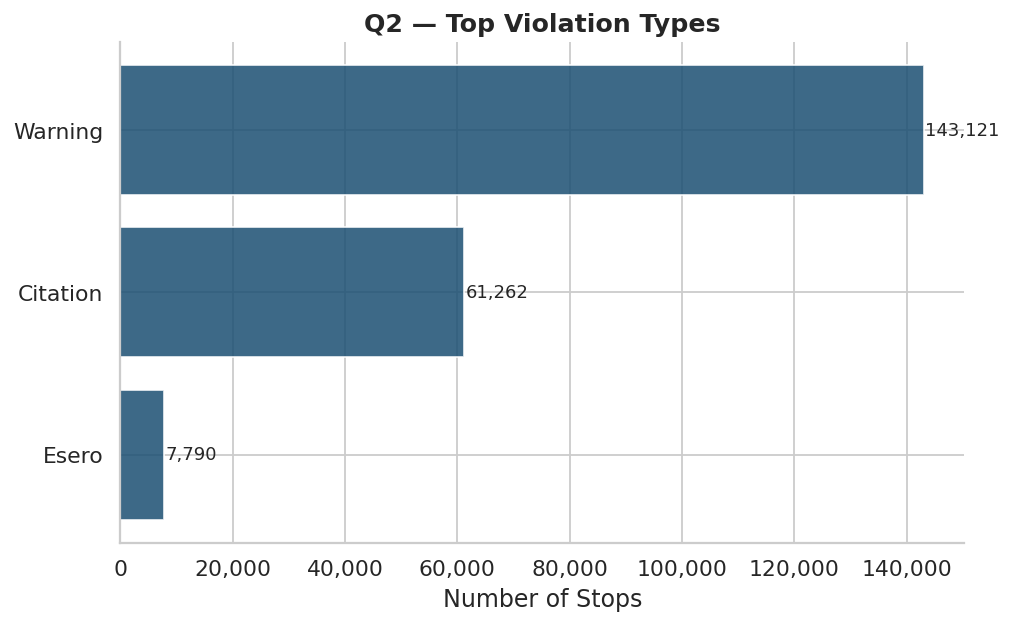

In [10]:
vtype = tv['violation_type'].value_counts().dropna().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(vtype.index[::-1], vtype.values[::-1], color=BLUE, alpha=0.85)
for i, v in enumerate(vtype.values[::-1]):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Q2 — Top Violation Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Stops')
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'q2_top_violation_types.png'), bbox_inches='tight')
plt.show()

## Q3 — Day of Week (+ Chi-Square Test)

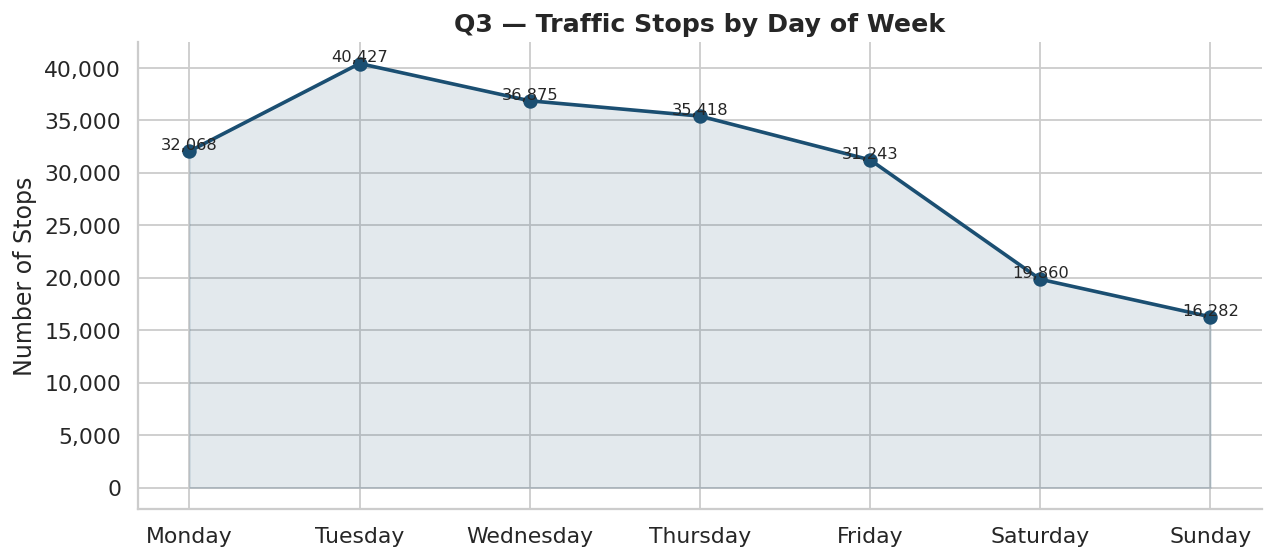

In [11]:
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = tv['day_of_week'].value_counts().reindex(day_order).dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(day_counts.index, day_counts.values, marker='o', linewidth=2, color=BLUE, markersize=7)
ax.fill_between(day_counts.index, day_counts.values, alpha=0.12, color=BLUE)
for d, v in zip(day_counts.index, day_counts.values):
    ax.text(d, v + 150, f'{v:,}', ha='center', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Q3 — Traffic Stops by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Number of Stops')
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'q3_stops_by_day_of_week.png'), bbox_inches='tight')
plt.show()

In [12]:
ct = pd.crosstab(tv['day_of_week'], tv['violation_type'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f'Chi² = {chi2:,.2f},  df = {dof},  p = {p:.4e}')

Chi² = 2,560.74,  df = 12,  p = 0.0000e+00


## Q5 — Geographic Heatmap

In [13]:
geo = (
    tv
    .dropna(subset=['latitude', 'longitude'])
    .query('38.9 <= latitude <= 39.4 and -77.7 <= longitude <= -76.9')
    .sample(20000, random_state=42)
)

m = folium.Map(location=[39.15, -77.2], zoom_start=11, tiles='CartoDB dark_matter')
HeatMap(geo[['latitude', 'longitude']].values.tolist(), radius=8, blur=12, min_opacity=0.4).add_to(m)
m.save(os.path.join(IMG, 'q5_geographic_heatmap.html'))
m

## Monthly Volume Trend

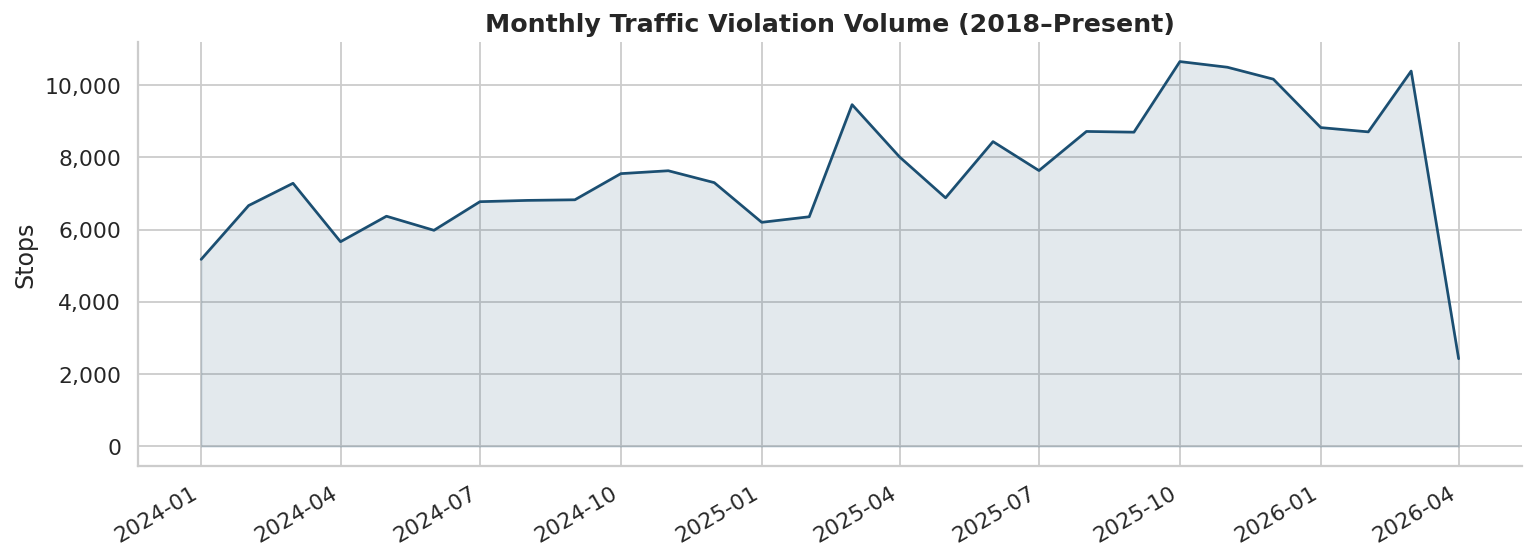

In [14]:
monthly = tv.groupby(tv['date_of_stop'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly.values, linewidth=1.5, color=BLUE)
ax.fill_between(monthly.index, monthly.values, alpha=0.12, color=BLUE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Monthly Traffic Violation Volume (2018–Present)', fontsize=14, fontweight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Stops')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'monthly_volume_trend.png'), bbox_inches='tight')
plt.show()

## Violation Type × Race Heatmap

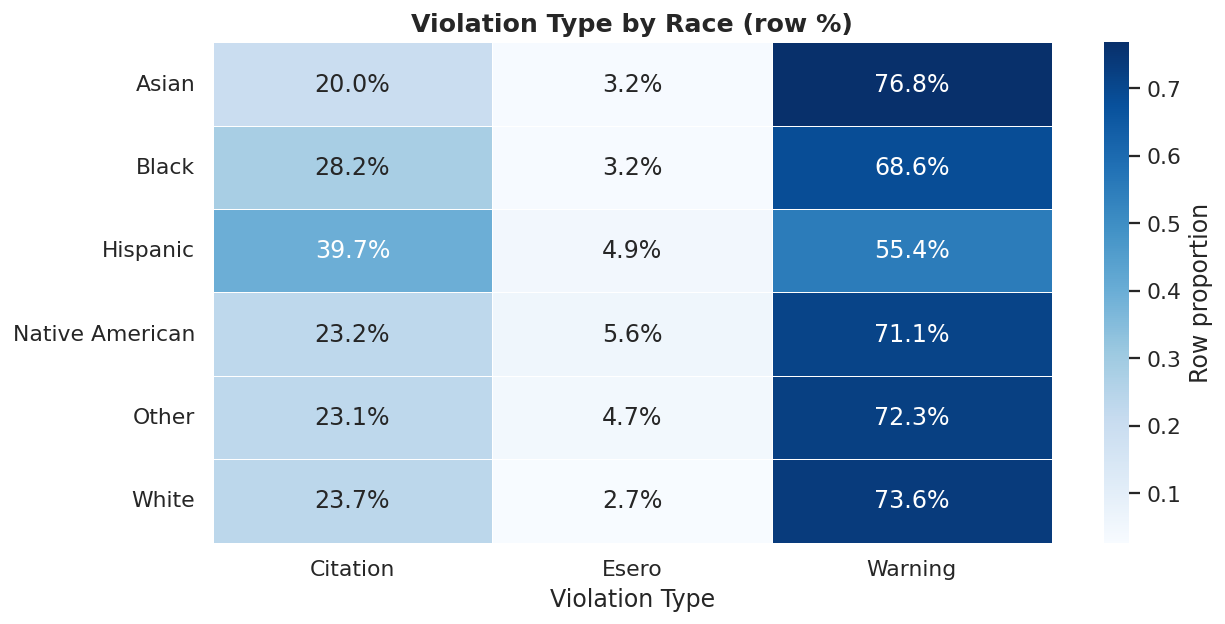

In [15]:
top_races  = tv['race'].value_counts().head(6).index
top_vtypes = tv['violation_type'].value_counts().head(5).index

ct2 = (
    tv[tv['race'].isin(top_races) & tv['violation_type'].isin(top_vtypes)]
    .pipe(lambda d: pd.crosstab(d['race'], d['violation_type'], normalize='index'))
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct2, annot=True, fmt='.1%', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Row proportion'})
ax.set_title('Violation Type by Race (row %)', fontsize=14, fontweight='bold')
ax.set_xlabel('Violation Type')
ax.set_ylabel(None)
plt.tight_layout()
plt.savefig(os.path.join(IMG, 'violation_type_by_race_heatmap.png'), bbox_inches='tight')
plt.show()